In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the libraries for a GLM.

In [13]:
#| echo: true
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

Generating the data.

In [14]:
#| echo: true
np.random.seed(42)
X = np.random.uniform(0, 3, 100)

mu = np.exp(1.2 * X + 0.5)
y = np.random.poisson(mu)

Creating and fitting the model.

In [15]:
#| echo: true
X_sm = sm.add_constant(X)

glm_model = sm.GLM(y, X_sm, family=sm.families.Poisson(link=sm.families.links.Log()))
glm_results = glm_model.fit()

print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -255.46
Date:                Fri, 24 Apr 2026   Deviance:                       120.93
Time:                        16:48:40   Pearson chi2:                     118.
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4624      0.088      5.240      0.0

Plotting the final result.

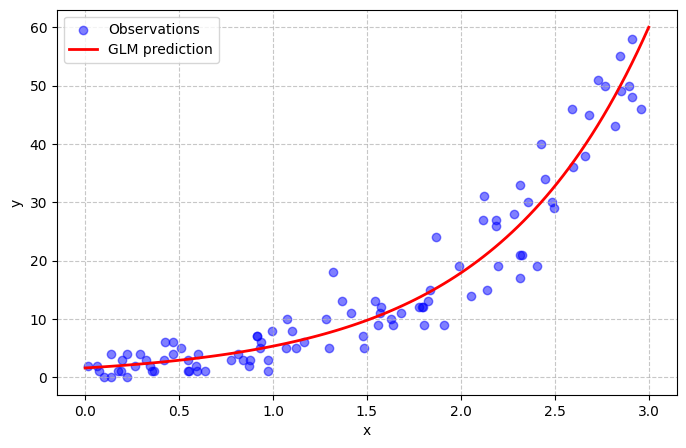

In [19]:
#| echo: true
X_test = np.linspace(0, 3, 100)
X_test_sm = sm.add_constant(X_test)
y_pred = glm_results.predict(X_test_sm)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.5, label='Observations')
plt.plot(X_test, y_pred, color='red', linewidth=2, label=r'GLM prediction')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()